# Import Library

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split

# Load Dataset (Excel)

In [ ]:
sheets1 = pd.read_excel('Customer_Churn_Data_Large.xlsx', sheet_name='Customer_Demographics')
sheets1.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


In [ ]:
sheet2 = pd.read_excel('Customer_Churn_Data_Large.xlsx', sheet_name='Transaction_History')
sheet2.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing


In [ ]:
sheet3 = pd.read_excel('Customer_Churn_Data_Large.xlsx', sheet_name='Customer_Service')
sheet3.head()

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved


In [ ]:
sheet4 = pd.read_excel('Customer_Churn_Data_Large.xlsx', sheet_name='Online_Activity')
sheet4.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website


In [ ]:
sheet5 = pd.read_excel('Customer_Churn_Data_Large.xlsx', sheet_name='Churn_Status')
sheet5.head()

,CustomerID,ChurnStatus
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


### Marge all existing sheet

In [ ]:
all_sheets = sheets1
all_sheets = pd.merge(all_sheets, sheet2, on='CustomerID', how='inner')
all_sheets = pd.merge(all_sheets, sheet3, on='CustomerID', how='inner')
all_sheets = pd.merge(all_sheets, sheet4, on='CustomerID', how='inner')
all_sheets = pd.merge(all_sheets, sheet5, on='CustomerID', how='inner')
all_sheets.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,7194,2022-03-27,416.50,Electronics,6363,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,7250,2022-08-08,54.96,Clothing,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
2,2,65,M,Married,Low,9660,2022-07-25,197.50,Electronics,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
3,2,65,M,Married,Low,2998,2022-01-25,101.31,Furniture,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
4,2,65,M,Married,Low,1228,2022-07-24,397.37,Clothing,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1


# EDA

In [ ]:
all_sheets.describe()

,CustomerID,Age,TransactionID,TransactionDate,AmountSpent,InteractionID,InteractionDate,LastLoginDate,LoginFrequency,ChurnStatus
count,5204.000000,5204.000000,5204.000000,5204,5204.000000,5204.000000,5204,5204,5204.000000,5204.000000
mean,496.470407,43.140085,5495.988470,2022-06-29 08:30:15.219062272,254.354940,5921.861261,2022-07-01 16:31:10.561106944,2023-07-04 09:27:31.960030720,25.918332,0.205995
min,1.000000,18.000000,1000.000000,2022-01-01 00:00:00,5.180000,2015.000000,2022-01-01 00:00:00,2023-01-01 00:00:00,1.000000,0.000000
25%,244.000000,29.000000,3218.000000,2022-03-30 00:00:00,128.940000,3873.250000,2022-04-07 00:00:00,2023-04-04 00:00:00,14.000000,0.000000
50%,504.000000,43.000000,5490.000000,2022-06-27 00:00:00,255.175000,5903.000000,2022-07-02 00:00:00,2023-07-11 00:00:00,27.000000,0.000000
75%,743.000000,57.000000,7713.000000,2022-09-28 00:00:00,378.605000,7851.000000,2022-09-25 00:00:00,2023-10-01 00:00:00,38.000000,0.000000
max,995.000000,69.000000,9997.000000,2022-12-31 00:00:00,499.700000,9997.000000,2022-12-30 00:00:00,2023-12-31 00:00:00,49.000000,1.000000
std,286.681289,15.430343,2595.575295,NaN,143.329654,2332.331260,NaN,NaN,14.110627,0.404466


In [ ]:
all_sheets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5204 entries, 0 to 5203
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        5204 non-null   int64         
 1   Age               5204 non-null   int64         
 2   Gender            5204 non-null   object        
 3   MaritalStatus     5204 non-null   object        
 4   IncomeLevel       5204 non-null   object        
 5   TransactionID     5204 non-null   int64         
 6   TransactionDate   5204 non-null   datetime64[ns]
 7   AmountSpent       5204 non-null   float64       
 8   ProductCategory   5204 non-null   object        
 9   InteractionID     5204 non-null   int64         
 10  InteractionDate   5204 non-null   datetime64[ns]
 11  InteractionType   5204 non-null   object        
 12  ResolutionStatus  5204 non-null   object        
 13  LastLoginDate     5204 non-null   datetime64[ns]
 14  LoginFrequency    5204 n

In [ ]:
all_sheets.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
MaritalStatus,0
IncomeLevel,0
TransactionID,0
TransactionDate,0
AmountSpent,0
ProductCategory,0
InteractionID,0


Distribution of number data type

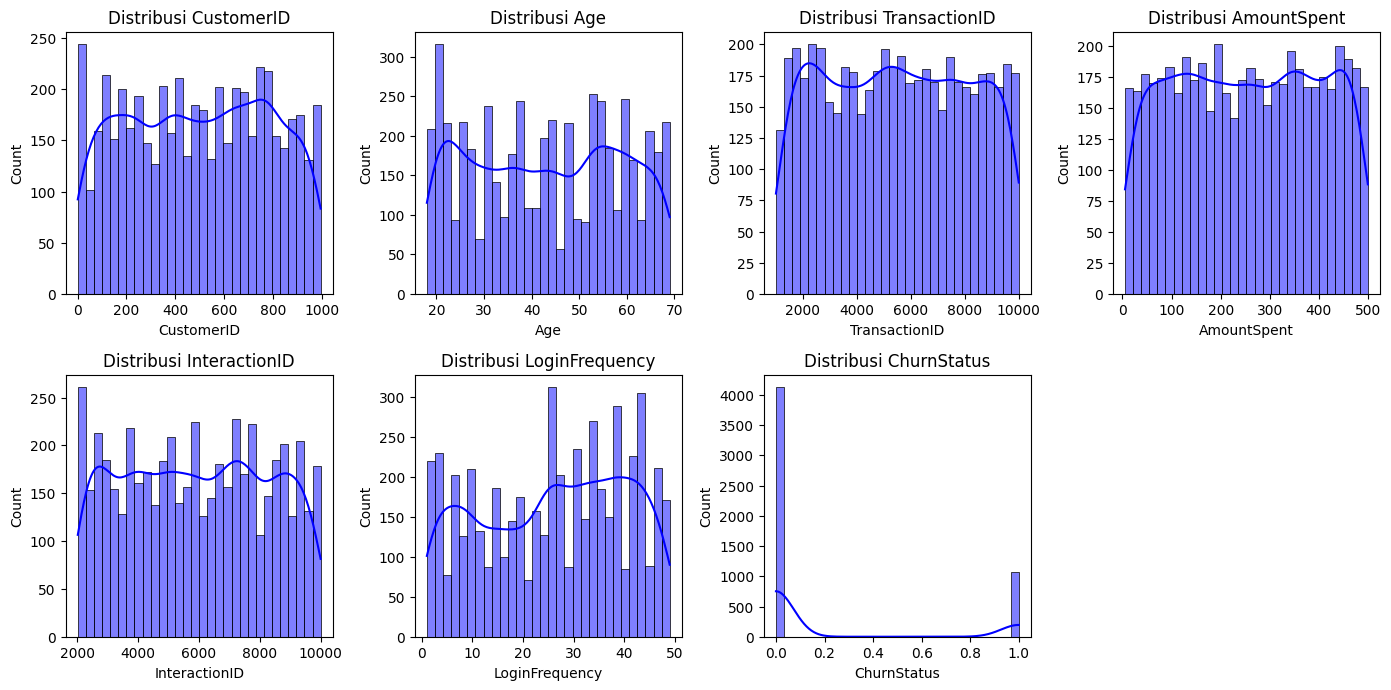

In [ ]:
num_features = all_sheets.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
for i, column in enumerate(num_features.columns, 1):
  plt.subplot(3, 4, i)
  sns.histplot(all_sheets[column], bins=30, kde=True, color='blue')
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

Distribution of category data type

/tmp/ipykernel_9326/1784555749.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=all_sheets[column], palette='pastel')
/tmp/ipykernel_9326/1784555749.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=all_sheets[column], palette='pastel')
/tmp/ipykernel_9326/1784555749.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=all_sheets[column], palette='pastel')
/tmp/ipykernel_9326/1784555749.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hu

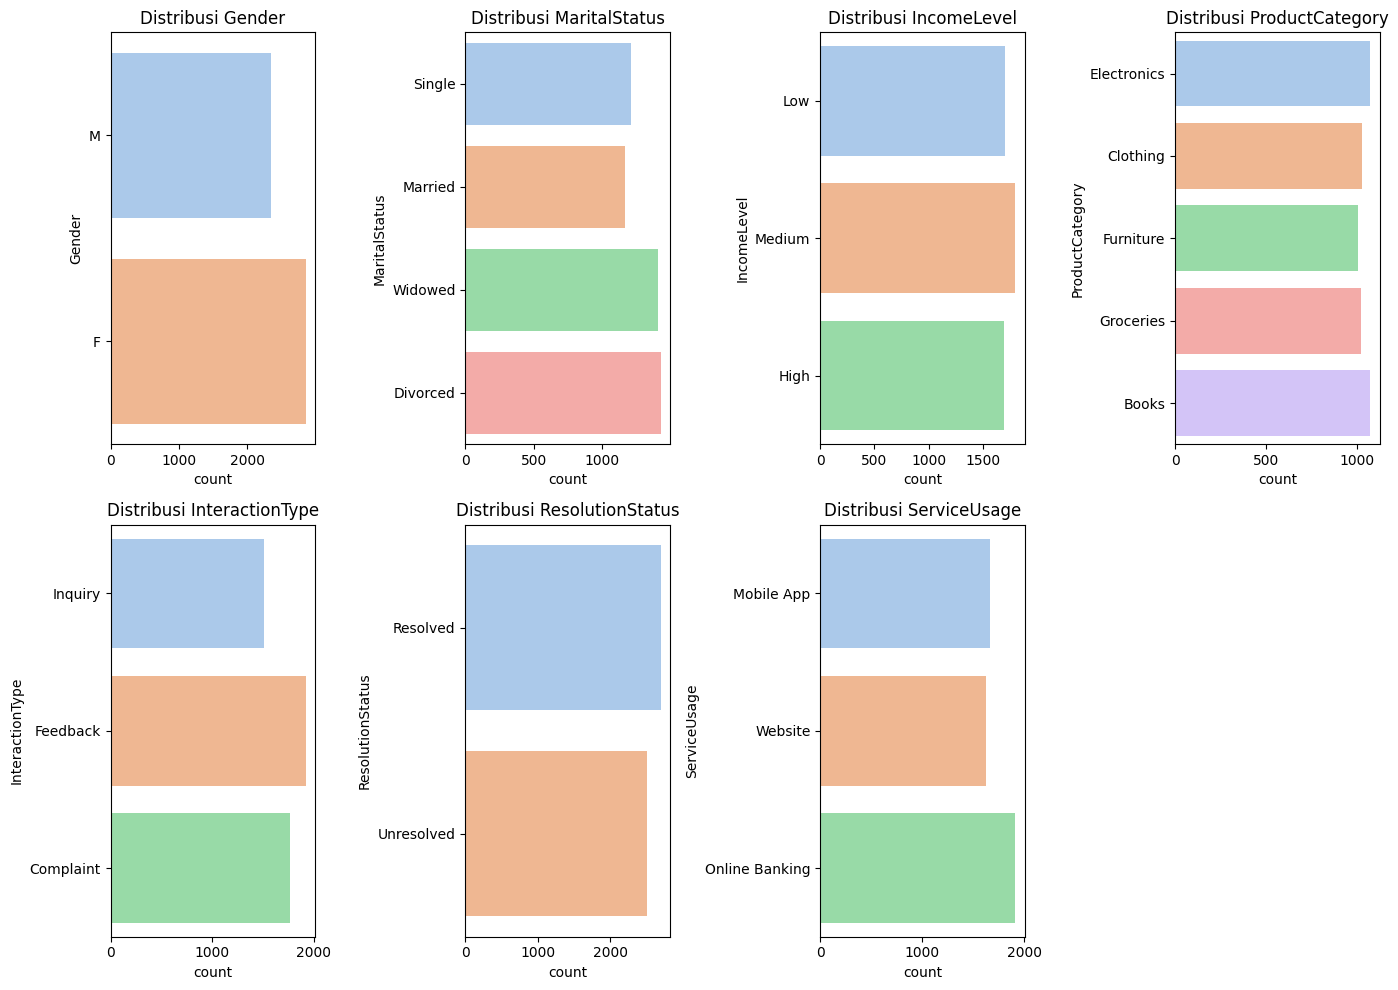

In [ ]:
cat_features = all_sheets.select_dtypes(include=[object])
plt.figure(figsize=(14, 10))
for i, column in enumerate(cat_features.columns, 1):
  plt.subplot(2, 4, i)
  sns.countplot(y=all_sheets[column], palette='pastel')
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

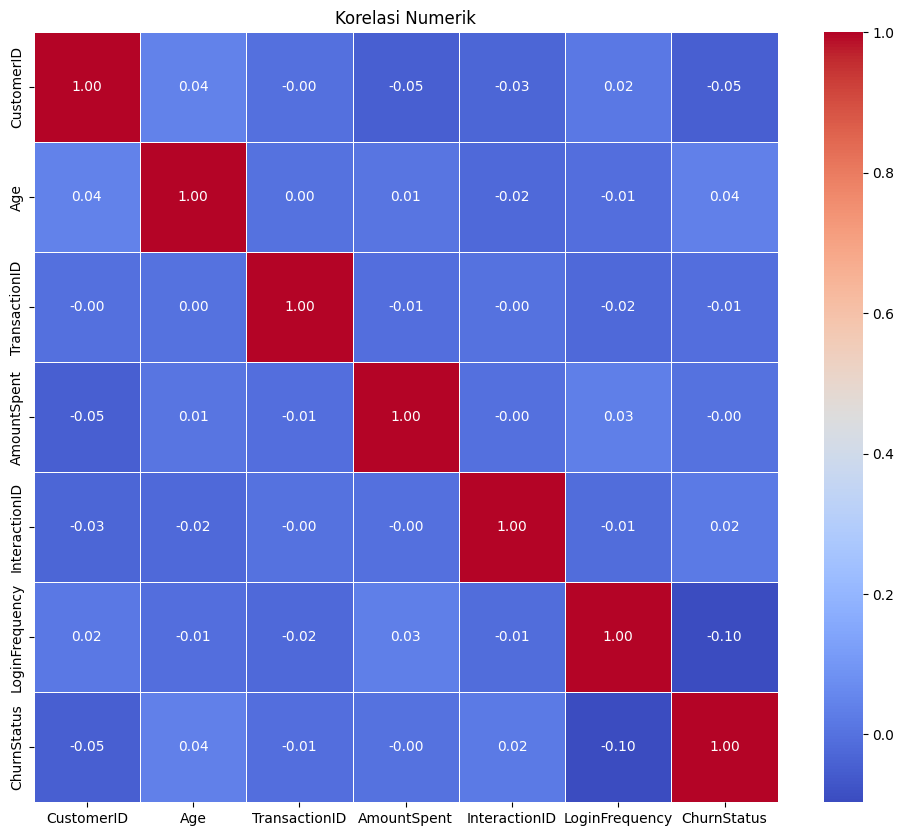

In [ ]:
plt.figure(figsize=(12, 10))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',fmt='.2f', linewidths=0.5)
plt.title('Korelasi Numerik')
plt.show()

In [ ]:
obj_cols = cat_features.columns.tolist()
target_sheet = "ChurnStatus"

if target_sheet in obj_cols:
    obj_cols.remove(target_sheet)

results=[]

for col in obj_cols:
    contingency_table = pd.crosstab(all_sheets[col], all_sheets[target_sheet])
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    cramer_v = np.sqrt(chi2/(n*min_dim)) if min_dim > 0 else 0

    results.append({
        'Feature': col,
        'Chi-Squared': chi2,
        'P-Value': p,
        'Cramers V': cramer_v,
        'Relevancy': 'High' if p < 0.05 else 'Low'
    })

results_df = pd.DataFrame(results).sort_values(by='Cramers V', ascending=False)
print(results_df)

            Feature  Chi-Squared   P-Value  Cramers V Relevancy
1     MaritalStatus    26.100652  0.000009   0.070820      High
6      ServiceUsage    20.809200  0.000030   0.063235      High
0            Gender    14.895547  0.000114   0.053501      High
2       IncomeLevel    10.916458  0.004261   0.045801      High
3   ProductCategory     4.971028  0.290283   0.030907       Low
4   InteractionType     0.375308  0.828901   0.008492       Low
5  ResolutionStatus     0.035697  0.850142   0.002619       Low


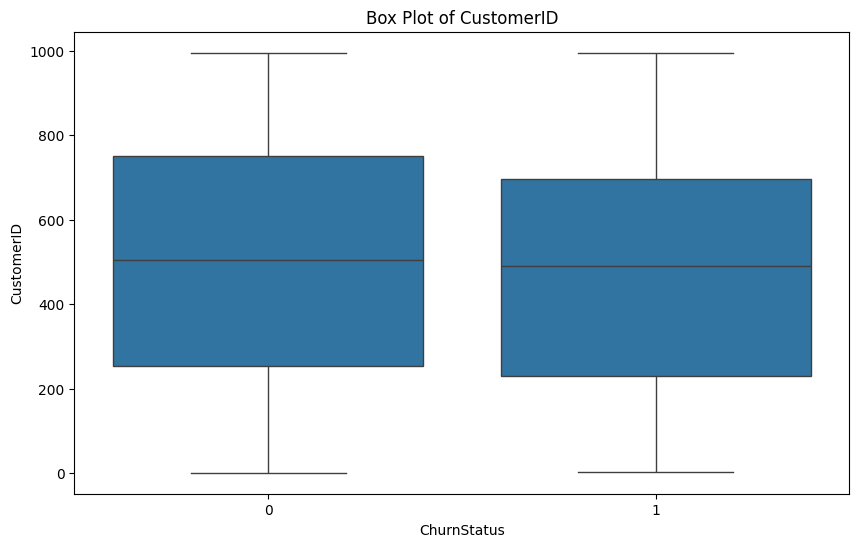

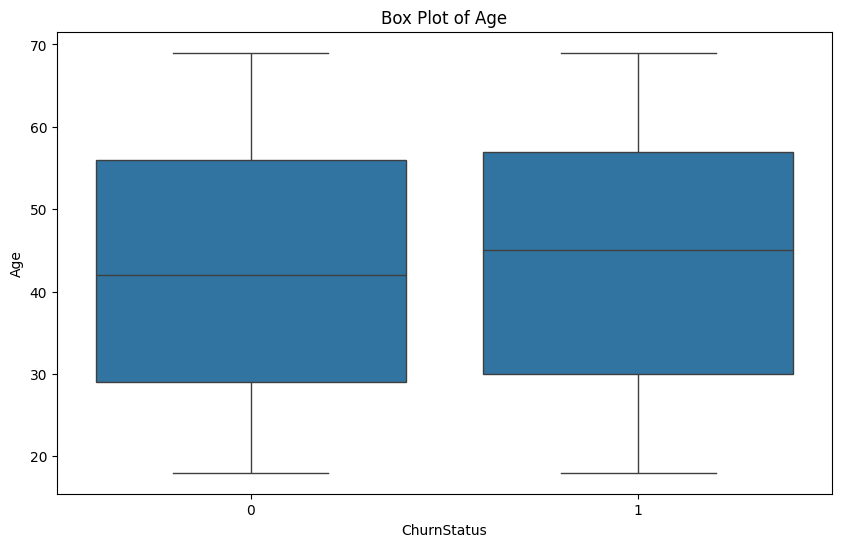

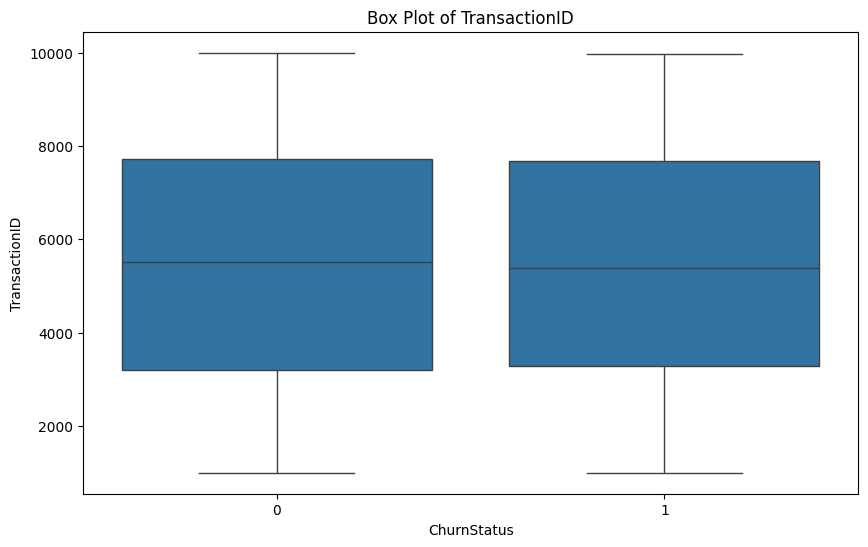

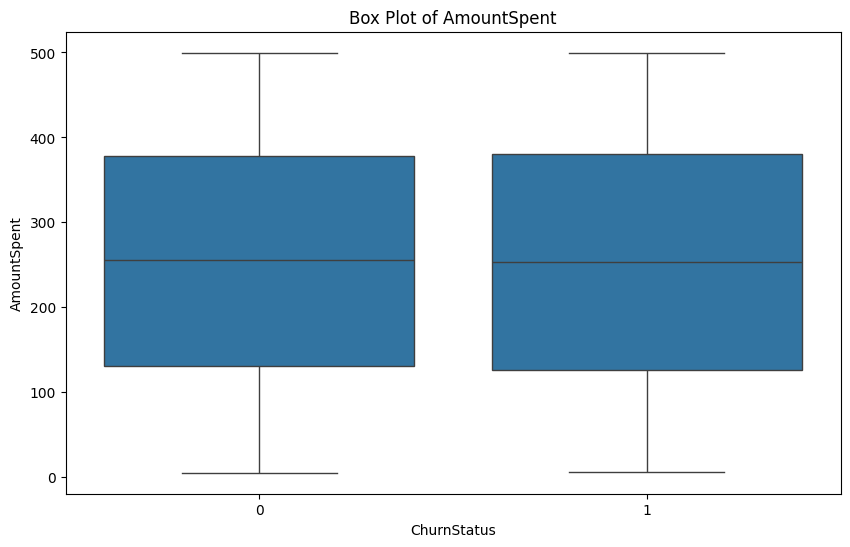

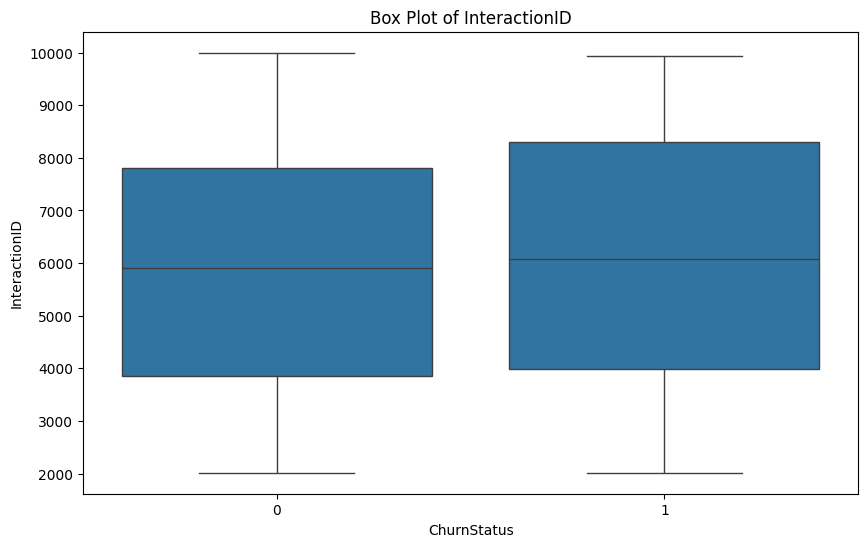

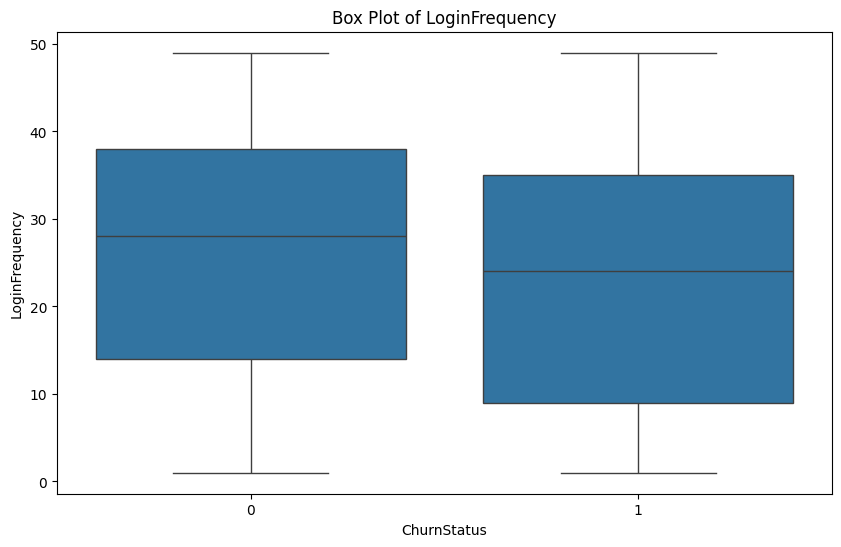

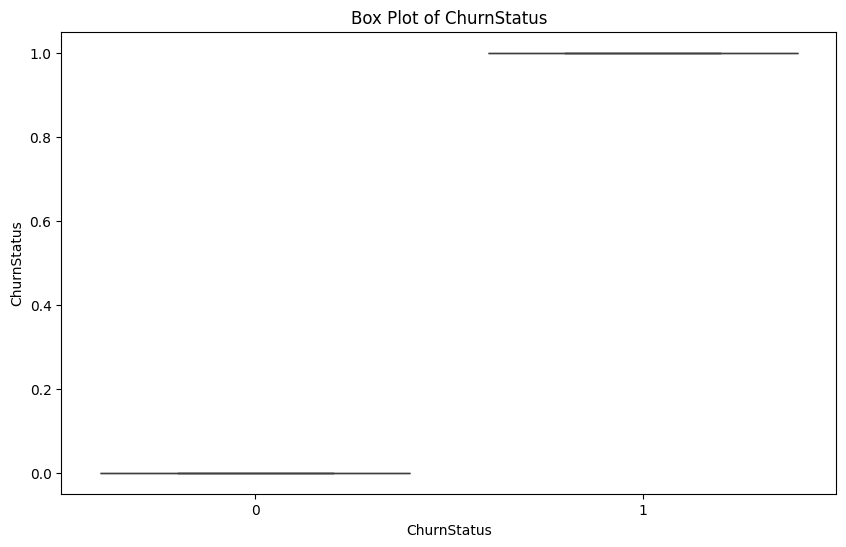

In [ ]:
for feature in num_features.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='ChurnStatus', y=feature, data=all_sheets)
    plt.title(f'Box Plot of {feature}')
    plt.show()

In [ ]:

categorical_non_hierarchical = ['Gender', 'ServiceUsage', 'MaritalStatus']


encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_cols_dfs = []

for col in categorical_non_hierarchical:

  col_data_reshaped = all_sheets[col].values.reshape(-1, 1)

  # Fit and transform the current column
  encoded_features = encoder.fit_transform(col_data_reshaped)

  # Get the new feature names (e.g., 'Gender_M', 'Gender_F')
  new_col_names = encoder.get_feature_names_out([col])

  # Create a DataFrame from the encoded features and add to the list
  encoded_df_for_col = pd.DataFrame(encoded_features, columns=new_col_names, index=all_sheets.index)
  encoded_cols_dfs.append(encoded_df_for_col)

# Drop the original categorical columns from all_sheets
all_sheets = all_sheets.drop(columns=categorical_non_hierarchical)

# Concatenate the original DataFrame (without original categorical columns) with the new encoded DataFrames
all_sheets = pd.concat([all_sheets] + encoded_cols_dfs, axis=1)

all_sheets.head()

,CustomerID,Age,IncomeLevel,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,...,ChurnStatus,Gender_F,Gender_M,ServiceUsage_Mobile App,ServiceUsage_Online Banking,ServiceUsage_Website,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed
0,1,62,Low,7194,2022-03-27,416.50,Electronics,6363,2022-03-31,Inquiry,...,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2,65,Low,7250,2022-08-08,54.96,Clothing,3329,2022-03-17,Inquiry,...,1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,2,65,Low,9660,2022-07-25,197.50,Electronics,3329,2022-03-17,Inquiry,...,1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,2,65,Low,2998,2022-01-25,101.31,Furniture,3329,2022-03-17,Inquiry,...,1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,2,65,Low,1228,2022-07-24,397.37,Clothing,3329,2022-03-17,Inquiry,...,1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
lc = LabelEncoder()
all_sheets['IncomeLevel'] = lc.fit_transform(all_sheets['IncomeLevel'])

all_sheets.head()

,CustomerID,Age,IncomeLevel,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,...,ChurnStatus,Gender_F,Gender_M,ServiceUsage_Mobile App,ServiceUsage_Online Banking,ServiceUsage_Website,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed
0,1,62,1,7194,2022-03-27,416.50,Electronics,6363,2022-03-31,Inquiry,...,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2,65,1,7250,2022-08-08,54.96,Clothing,3329,2022-03-17,Inquiry,...,1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,2,65,1,9660,2022-07-25,197.50,Electronics,3329,2022-03-17,Inquiry,...,1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,2,65,1,2998,2022-01-25,101.31,Furniture,3329,2022-03-17,Inquiry,...,1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,2,65,1,1228,2022-07-24,397.37,Clothing,3329,2022-03-17,Inquiry,...,1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
all_sheets_new = all_sheets.drop(columns=['CustomerID', 'TransactionID', 'InteractionID', 'TransactionDate', 'InteractionDate', 'ProductCategory', 'InteractionType', 'ResolutionStatus', 'LastLoginDate'])
all_sheets_new.head()

,Age,IncomeLevel,AmountSpent,LoginFrequency,ChurnStatus,Gender_F,Gender_M,ServiceUsage_Mobile App,ServiceUsage_Online Banking,ServiceUsage_Website,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed
0,62,1,416.50,34,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,65,1,54.96,5,1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,65,1,197.50,5,1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,65,1,101.31,5,1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,65,1,397.37,5,1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
X = all_sheets_new.drop(columns=['ChurnStatus'])
y = all_sheets_new['ChurnStatus']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Menghitung rasio data Churn status
ratio = float(y_train.value_counts()[1] / y_train.value_counts()[0])

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    scale_pos_weight=2,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train) # Training data

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:32:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


print("\nROC AUC Score:", roc_auc_score(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       827
           1       0.87      0.83      0.85       214

    accuracy                           0.94      1041
   macro avg       0.91      0.90      0.90      1041
weighted avg       0.94      0.94      0.94      1041


ROC AUC Score: 0.897227338991287


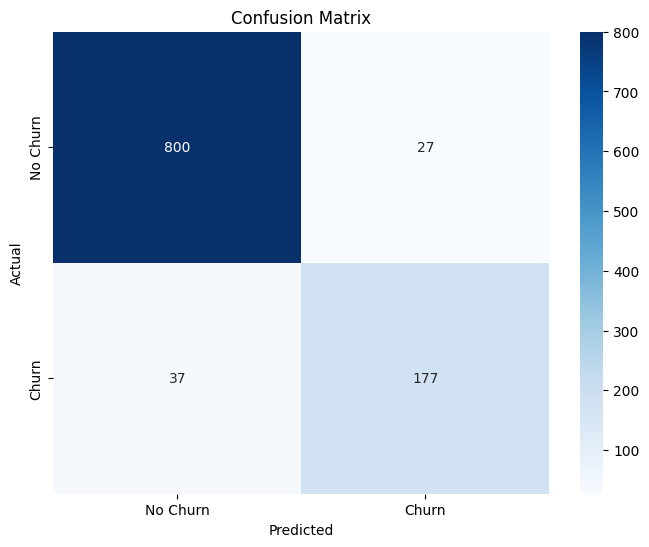

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

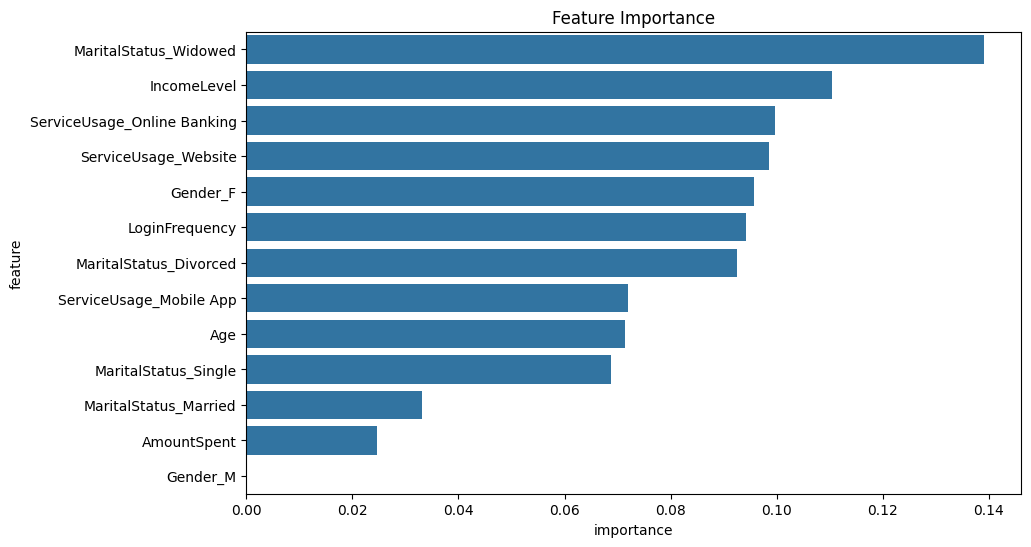

In [ ]:
feature_import = xgb_model.feature_importances_

feature_import_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_import
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_import_df)
plt.title('Feature Importance')
plt.show()